# PyroScout: finding people with heat and light

A walk-through of PyroScout, a small 2D simulator for a search-and-rescue
robot that fuses a LIDAR and a thermal sensor.

The setup: a robot rolls into a smoke-filled building it has never seen.
Somewhere inside is a person who needs help. The robot has two senses:

* a LIDAR, which measures distances to surfaces. It tells the robot where the
  walls are, but not what matters.
* a thermal sensor, which sees body heat. It tells the robot where the person
  is, but nothing about the walls in between.

Neither sense is enough alone, so the robot fuses them: explore the unknown,
detect the heat, plan a safe path, and drive to the victim without hitting a
wall.

![PyroScout demo](../assets/demo.gif)

Left: the ground truth the robot can't see. Right: the map it builds from
LIDAR, with its live plan drawn on top.

In the run above the robot reaches the victim with no collisions and localises
them to within a couple of centimetres, purely from noisy sensor data. The
rest of this notebook builds the system up one layer at a time.

## Geometry vs. semantics

The design hinges on a separation that shows up all over robotics. The LIDAR
measures distance to surfaces: it builds the map, but has no idea what is
important. The thermal sensor measures radiated heat: it picks the goal, but
has no idea what is in the way. The robot's "brain" turns the pair into a
loop:

```
       sense ──▶ map (LIDAR)  ──▶ plan ──▶ control ──▶ move
         │        goal (thermal) ──┘                     │
         └──────────────────────────────────────────────┘
```

Everything below is a layer of that loop.

## Setup

Install the package (`pip install -e .` from the repo) and import the pieces.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as MRect, Circle
from matplotlib.collections import LineCollection

plt.rcParams.update({"figure.figsize": (8, 5), "figure.dpi": 110})

from pyroscout.world import World, Rectangle, HeatSource
from pyroscout.geometry import Pose
from pyroscout.sensors import Lidar2D, ThermalSensor
from pyroscout.mapping import OccupancyGrid
from pyroscout.planning import astar
from pyroscout.scenarios import demo_navigator, search_rescue_world
from pyroscout.navigator import Navigator, NavState

print("PyroScout ready.")

PyroScout ready.


## 1. The world

The test environment is a small three-room building. The two interior walls
have offset doorways, so the robot has to wind through the middle room, and it
cannot see the victim's heat from the start because walls block infrared. The
robot begins blind in the left room (blue); the victim (red star) is in the
far right room.

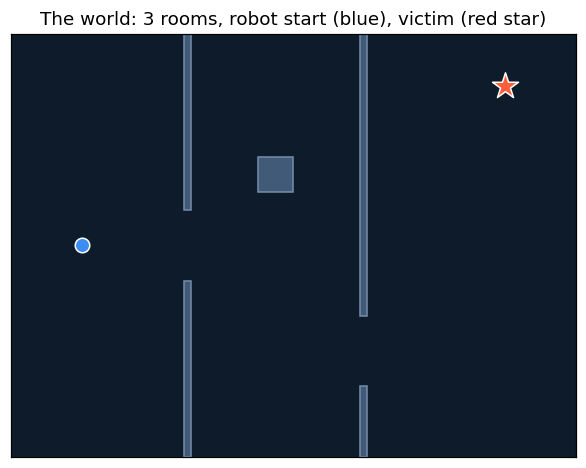

In [2]:
def draw_world(ax, world):
    ax.set_aspect("equal"); ax.set_xlim(0, world.width); ax.set_ylim(0, world.height)
    ax.set_facecolor("#0d1b2a"); ax.set_xticks([]); ax.set_yticks([])
    for o in world.obstacles:
        ax.add_patch(MRect((o.x, o.y), o.w, o.h, facecolor="#415a77", edgecolor="#778da9"))
    for s in world.heat_sources:
        ax.scatter(s.x, s.y, marker="*", s=320, color="#ff5d3b", edgecolors="white", zorder=5)

world, start = search_rescue_world()
fig, ax = plt.subplots()
draw_world(ax, world)
ax.scatter(start.x, start.y, marker="o", s=90, color="#3b8df4", edgecolors="white", zorder=5)
ax.set_title("The world: 3 rooms, robot start (blue), victim (red star)")
plt.show()

## 2. LIDAR

A LIDAR fires laser beams in many directions and times the reflections. The
simulation ray-casts each beam and finds the nearest wall segment it strikes,
doing all beams against all walls in one vectorised linear-algebra step, then
adds a little noise to mimic a real sensor.

Below is a single 360° sweep from the start position. Note the shadows: the
robot only learns about surfaces it can actually see.

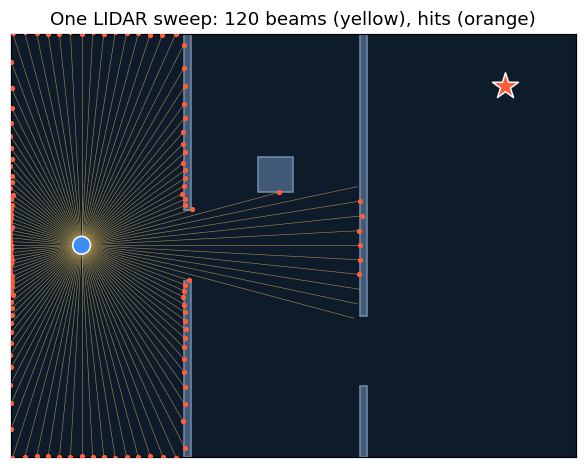

In [3]:
lidar = Lidar2D(num_beams=120, max_range=8.0, noise_std=0.03, seed=0)
scan = lidar.scan(start, world)

fig, ax = plt.subplots()
draw_world(ax, world)
ends = scan.endpoints()
ax.add_collection(LineCollection([[(start.x, start.y), tuple(e)] for e in ends],
                                 colors="#ffd166", linewidths=0.4, alpha=0.6))
ax.scatter(ends[scan.hit_mask, 0], ends[scan.hit_mask, 1], s=6, color="#ff5d3b", zorder=4)
ax.add_patch(Circle((start.x, start.y), 0.25, facecolor="#3b8df4", edgecolor="white", zorder=6))
ax.set_title(f"One LIDAR sweep: {lidar.num_beams} beams (yellow), hits (orange)")
plt.show()

## 3. The thermal sensor

Heat radiates and falls off with the square of distance, so a source of strength
$I_0$ at distance $d$ reads:

$$\text{measured} = \frac{I_0}{d^2 + 1}$$

That relationship is invertible, so a calibrated sensor can turn a raw
intensity reading back into a range estimate:
$d_\text{est} = \sqrt{I_0/\text{measured} - 1}$. Combined with the bearing,
one reading becomes a position estimate for the victim.

Two things make it realistic, and make the search hard. Walls block infrared,
so the victim is only detected with clear line of sight; from the start
position the robot has to physically get around corners first. And both
bearing and intensity are noisy, so the estimate is smoothed over time.

In [4]:
thermal = ThermalSensor(fov=np.pi, max_range=30.0, seed=0)

print("From the start (victim behind two walls):")
print("   detections:", thermal.sense(start, world), "  <- blocked by occlusion\n")

los_pose = Pose(12.0, 8.0, 0.9)  # standing in the right room, facing the victim
dets = thermal.sense(los_pose, world)
print("From inside the right room (clear line of sight):")
for d in dets:
    est = d.estimated_position(los_pose)
    print(f"   bearing={np.degrees(d.bearing):.1f} deg, "
          f"est. range={d.est_range:.2f} m -> est. position=({est[0]:.2f}, {est[1]:.2f})")
print("   true victim position:", tuple(world.heat_sources[0].xy))

From the start (victim behind two walls):
   detections: []   <- blocked by occlusion

From inside the right room (clear line of sight):
   bearing=51.1 deg, est. range=3.19 m -> est. position=(14.00, 10.48)
   true victim position: (np.float64(14.0), np.float64(10.5))


We can also visualise the underlying thermal *field* the sensor samples from — bright where it's hot, fading with distance:

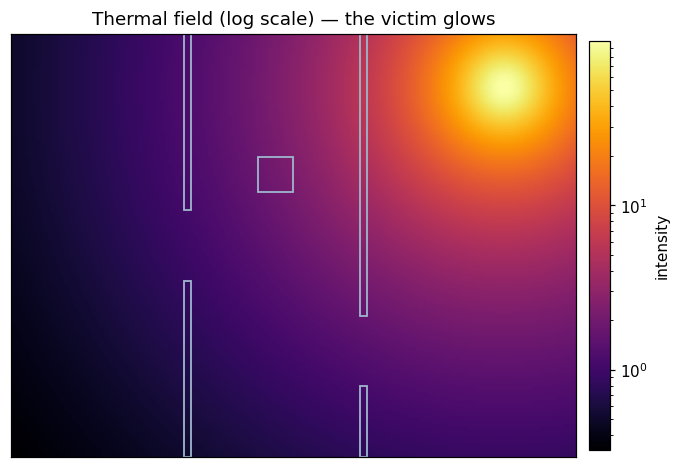

In [5]:
xs, ys = np.meshgrid(np.linspace(0, world.width, 200), np.linspace(0, world.height, 150))
field = thermal.field_at(xs, ys, world)

fig, ax = plt.subplots()
im = ax.imshow(field, origin="lower", extent=(0, world.width, 0, world.height),
               cmap="inferno", norm="log")
for o in world.obstacles:
    ax.add_patch(MRect((o.x, o.y), o.w, o.h, facecolor="none", edgecolor="#9db4cc", lw=1.2))
ax.set_title("Thermal field (log scale) — the victim glows"); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="intensity")
plt.show()

## 4. Mapping

The robot starts with no map. Every LIDAR sweep updates an occupancy grid that
stores, per cell, the log-odds of being occupied:

$$\ell = \log\frac{p(\text{occupied})}{p(\text{free})}$$

Log-odds make the Bayesian update an addition: cells a beam passes through get
"more free", the cell it lands in gets "more occupied". Starting from
$\ell = 0$ (unknown), the map sharpens as evidence builds.

Here the full robot runs once and we compare the map early in the run against
the end.

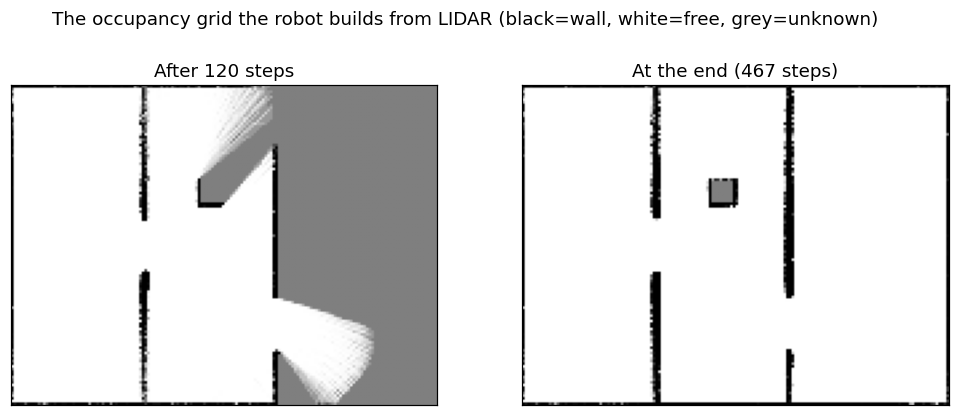

In [6]:
nav, world, robot = demo_navigator(seed=0)
result = nav.run(max_steps=700)

early_idx = min(120, len(result.history) - 1)
early = result.history[early_idx].grid_prob
late = nav.grid.prob

fig, axs = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, data, title in [(axs[0], early, f"After {early_idx} steps"),
                        (axs[1], late, f"At the end ({result.steps} steps)")]:
    ax.imshow(data, origin="lower", extent=(0, world.width, 0, world.height),
              cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("The occupancy grid the robot builds from LIDAR (black=wall, white=free, grey=unknown)")
plt.show()

## 5. Planning

Given a map and a goal, A\* finds the optimal path on the grid. Two details
matter for a physical robot. Diagonal moves that would clip a wall corner are
forbidden. And plain shortest-path hugs walls and scrapes doorway corners, so
a cost field computed from a distance transform penalises cells near walls,
pushing the planner towards the middle of corridors.

The difference shows when the same start-to-victim route is planned both ways:

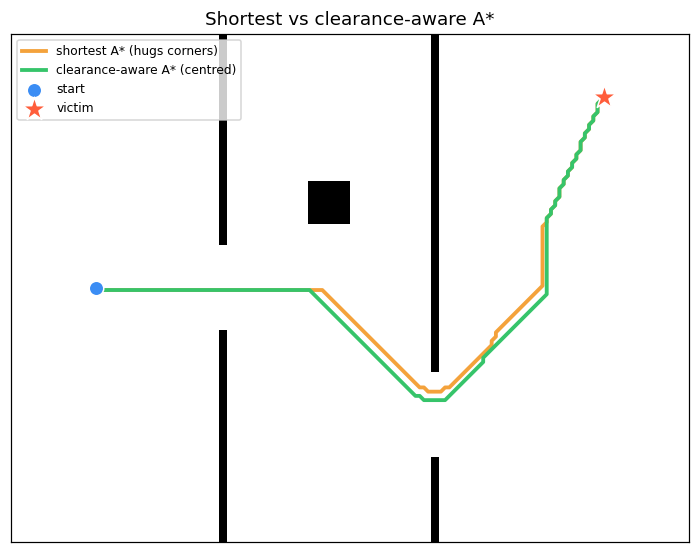

In [7]:
from pyroscout.navigator import _nearest_free

def rasterise(world, res=0.1):
    g = OccupancyGrid(world.width, world.height, res)
    for cy in range(g.ny):
        for cx in range(g.nx):
            wx, wy = g.grid_to_world(cx, cy)
            g.log_odds[cy, cx] = g.l_clamp if world.in_collision(wx, wy) else -g.l_clamp
    return g

def plan(g, s_xy, g_xy, inflate, weight):
    blocked = g.costmap(inflate_radius=inflate)
    s = _nearest_free(blocked, g.world_to_grid(*s_xy))
    t = _nearest_free(blocked, g.world_to_grid(*g_xy))
    cost = weight * np.maximum(0.0, 0.7 - g.clearance_m()) if weight else None
    return np.array([g.grid_to_world(cx, cy) for cx, cy in astar(blocked, s, t, cost_grid=cost)])

grid = rasterise(world)
goal_xy = world.heat_sources[0].xy
naive = plan(grid, start.xy, goal_xy, 0.45, 0.0)
safe  = plan(grid, start.xy, goal_xy, 0.45, 5.0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(grid.prob, origin="lower", extent=(0, world.width, 0, world.height), cmap="gray_r", vmin=0, vmax=1)
ax.plot(naive[:, 0], naive[:, 1], color="#f4a23b", lw=2.5, label="shortest A* (hugs corners)")
ax.plot(safe[:, 0], safe[:, 1], color="#36c46a", lw=2.5, label="clearance-aware A* (centred)")
ax.scatter(*start.xy, c="#3b8df4", s=90, edgecolors="white", zorder=5, label="start")
ax.scatter(*goal_xy, marker="*", s=260, c="#ff5d3b", edgecolors="white", zorder=5, label="victim")
ax.legend(loc="upper left", fontsize=8); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Shortest vs clearance-aware A*")
plt.show()

## 6. Control and fusion

Two final pieces turn a plan into motion and motion into a mission.

Pure-pursuit control converts the path into velocity commands by steering
toward a "carrot" point a fixed lookahead distance ahead — simple, smooth, and
the workhorse of real path followers.

The behaviour state machine is where the two senses fuse:

* `SEARCHING` — no victim seen yet, so use frontier exploration: drive to the
  boundary between mapped and unknown space to grow the map. Frontiers are
  clustered and chosen by a proximity-vs-size trade-off, with commitment and
  visited-memory so the robot doesn't dither.
* `NAVIGATING` — the instant thermal gets line of sight, plan to the fused
  victim estimate and follow it, replanning as the map grows. If the victim
  isn't reachable yet, explore toward it, mapping around the blocking wall.
* `REACHED` — arrived.

Here's the path the robot actually drove, over the final map it built:

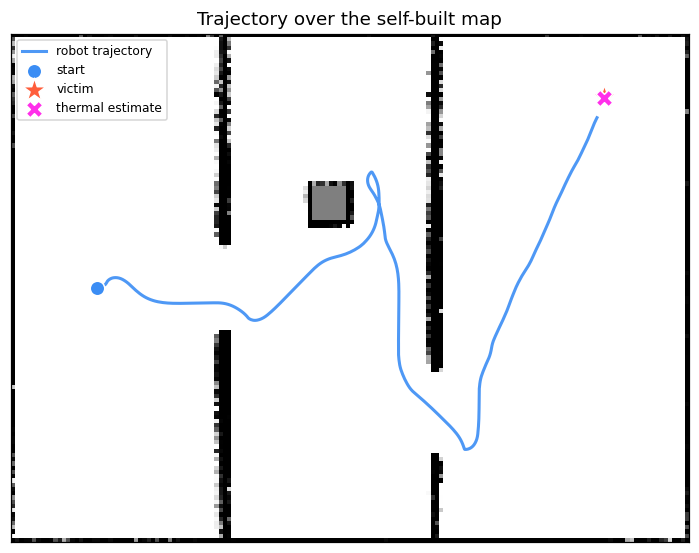

Outcome        : REACHED
Steps          : 467  (46.7 s simulated)
Distance       : 25.1 m
Collisions     : 0
Localisation   : 1.2 cm from the true victim position


In [8]:
xs = [r.pose.x for r in result.history]
ys = [r.pose.y for r in result.history]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(nav.grid.prob, origin="lower", extent=(0, world.width, 0, world.height), cmap="gray_r", vmin=0, vmax=1)
ax.plot(xs, ys, color="#3b8df4", lw=2, alpha=0.9, label="robot trajectory")
ax.scatter(xs[0], ys[0], c="#3b8df4", s=90, edgecolors="white", zorder=5, label="start")
ax.scatter(*world.heat_sources[0].xy, marker="*", s=260, c="#ff5d3b", edgecolors="white", zorder=5, label="victim")
if result.goal_estimate is not None:
    ax.scatter(*result.goal_estimate, marker="X", s=120, c="#ff2eea", edgecolors="white", zorder=6, label="thermal estimate")
ax.legend(loc="upper left", fontsize=8); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Trajectory over the self-built map")
plt.show()

err = float(np.hypot(*(result.goal_estimate - world.heat_sources[0].xy)))
print(f"Outcome        : {'REACHED' if result.success else result.state.value}")
print(f"Steps          : {result.steps}  ({result.sim_time:.1f} s simulated)")
print(f"Distance       : {result.path_length:.1f} m")
print(f"Collisions     : {result.collisions}")
print(f"Localisation   : {err*100:.1f} cm from the true victim position")

## Putting it together

That trajectory is the whole stack working at once: the robot sweeps the left
and middle rooms (frontier exploration), threads the offset doorways
(clearance-aware planning), catches the victim's heat the moment it rounds the
last corner (thermal + occlusion), fuses that into a centimetre-accurate goal,
and drives home (pure pursuit) with no collisions along the way.

A few directions this could go next: a particle filter would drop the
perfect-odometry assumption and make it proper SLAM; a local planner such as
the Dynamic Window Approach would handle moving obstacles; and the
architecture maps directly onto real data — a 3D LIDAR projected to 2D plus a
thermal camera's detections.

The full source, tests and CI live in the repository root.